# Notebook 4 — Multivariate Analysis

**TruBridge Externship | Iowa Colorectal Cancer (2016–2020)**

Combines outputs from Notebooks 1–3 for comprehensive multivariate analysis across all SDOH factors.

> **Prerequisites:** Run Notebooks 1, 2, and 3 first and upload all three exported CSVs to Colab before running.

## 0. Setup

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings; warnings.filterwarnings('ignore')


## 1. Load and merge all SDOH datasets

In [9]:
# ── Load the three CSVs produced by Notebooks 1-3 ────────────────────────────
health_df  = pd.read_csv('iowa_colorectal_cancer_health_sdoh_2016-2020.csv')
poverty_df = pd.read_csv('iowa_colorectal_cancer_poverty_sdoh_2016-2020.csv')
rent_df    = pd.read_csv('iowa_colorectal_cancer_rent_sdoh_2016-2020.csv')
print(f"Health: {health_df.shape} | Poverty: {poverty_df.shape} | Rent: {rent_df.shape}")

poverty_cols = ['County'] + [c for c in poverty_df.columns if 'Poverty' in c]
rent_cols    = ['County'] + [c for c in rent_df.columns if c.startswith('pct_')]

merged = (health_df
          .merge(poverty_df[poverty_cols], on='County', how='inner')
          .merge(rent_df[rent_cols],       on='County', how='inner'))
merged['Black_Poverty'] = merged['Black_Poverty'].fillna(merged['Black_Poverty'].median())
print(f"Merged: {merged.shape[0]} counties (expected 99)")

outcome_vars   = ['Number of New Cases per 100K','Cancer Risk Probability']
insurance_vars = ['pct_uninsured_35_64','pct_employer_only_35_64','pct_medicaid_only_35_64',
                  'pct_private_insurance_35_64','pct_government_insurance_35_64']
poverty_vars   = ['Overall_Poverty','Child_Poverty','Senior_Poverty',
                  'Low_Education_Poverty','Unemployment_Poverty']
rent_vars      = ['pct_Rent_Burdened_30pct_Plus','pct_Severely_Rent_Burdened']
predictor_vars = insurance_vars + poverty_vars + rent_vars
all_vars       = outcome_vars + predictor_vars

missing_cols = [c for c in all_vars if c not in merged.columns]
if missing_cols: print(f"WARNING — missing columns: {missing_cols}")
else: print("All expected columns present ✓")

analysis_df = merged[['County'] + all_vars].dropna().reset_index(drop=True)
print(f"Counties with complete data: {len(analysis_df)} (dropped {len(merged)-len(analysis_df)} with NaN)")
merged.to_csv('iowa_colorectal_cancer_multivariate_sdoh_2016-2020.csv', index=False)


Health: (99, 50) | Poverty: (99, 16) | Rent: (99, 18)
Merged: 99 counties (expected 99)
All expected columns present ✓
Counties with complete data: 99 (dropped 0 with NaN)


## 2. Correlation analysis and regression

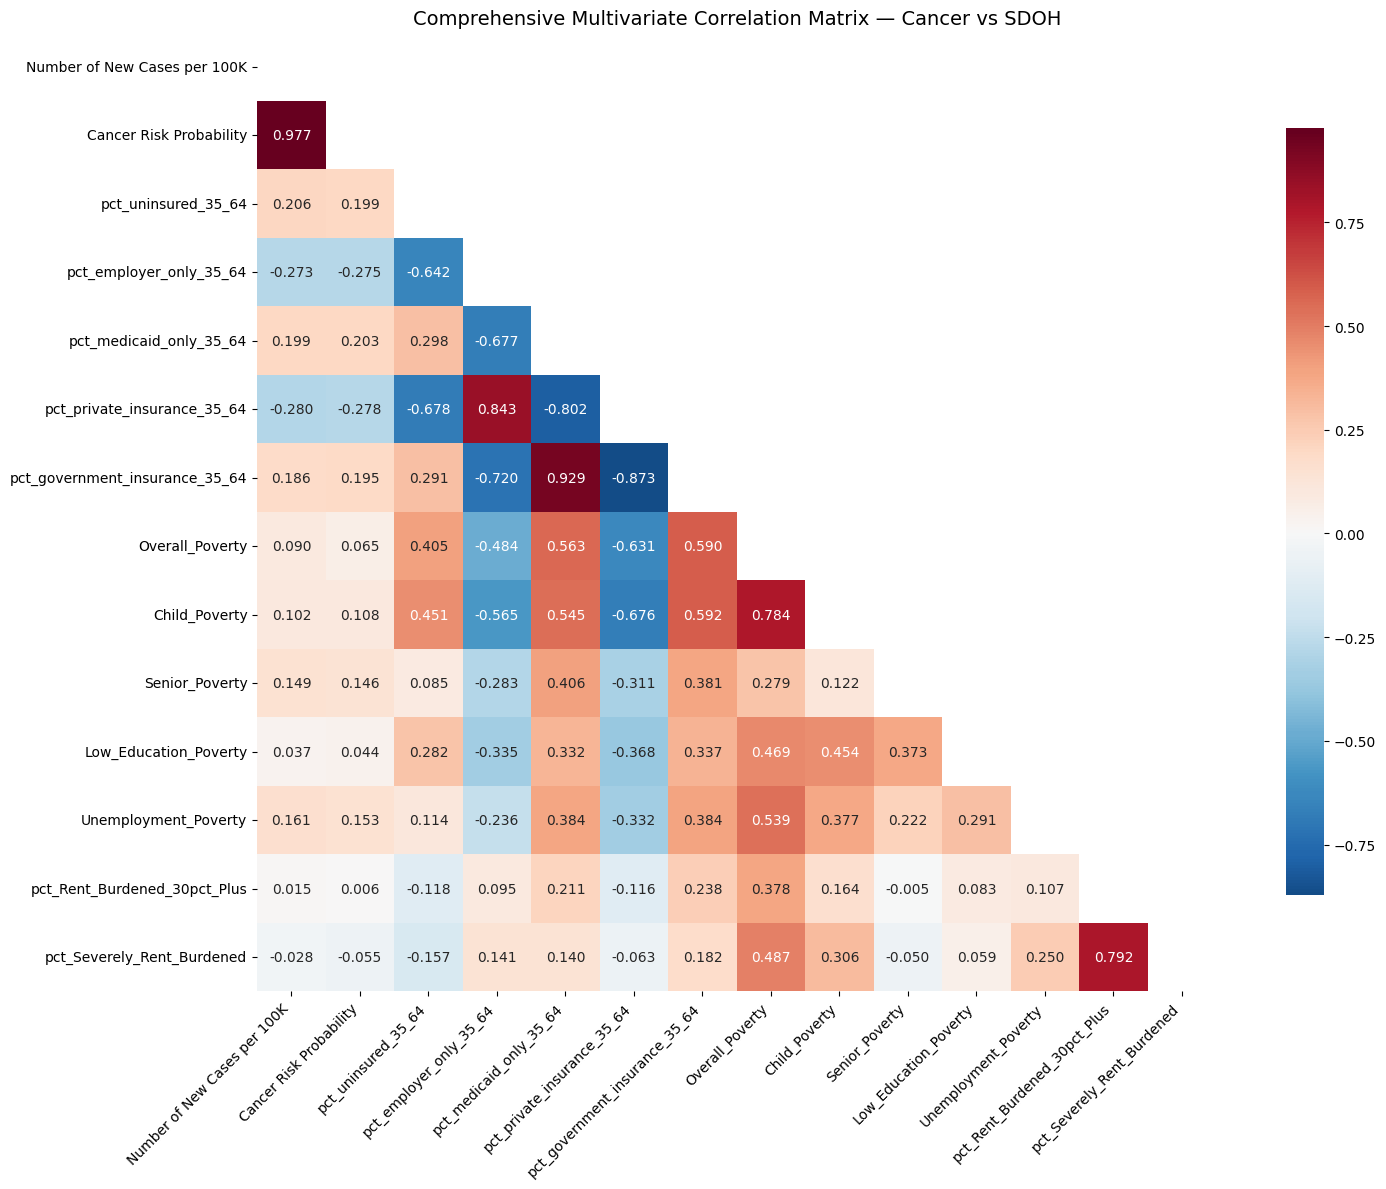


NUMBER OF NEW CASES PER 100K — predictors ranked by |r|:
  pct_private_insurance_35_64         r=-0.280  p=0.005 **
  pct_employer_only_35_64             r=-0.273  p=0.006 **
  pct_uninsured_35_64                 r=+0.206  p=0.040 *
  pct_medicaid_only_35_64             r=+0.199  p=0.049 *
  pct_government_insurance_35_64      r=+0.186  p=0.066 
  Unemployment_Poverty                r=+0.161  p=0.112 
  Senior_Poverty                      r=+0.149  p=0.142 
  Child_Poverty                       r=+0.102  p=0.317 
  Overall_Poverty                     r=+0.090  p=0.376 
  Low_Education_Poverty               r=+0.037  p=0.717 
  pct_Severely_Rent_Burdened          r=-0.028  p=0.785 
  pct_Rent_Burdened_30pct_Plus        r=+0.015  p=0.885 

CANCER RISK PROBABILITY — predictors ranked by |r|:
  pct_private_insurance_35_64         r=-0.278  p=0.005 **
  pct_employer_only_35_64             r=-0.275  p=0.006 **
  pct_medicaid_only_35_64             r=+0.203  p=0.044 *
  pct_uninsured_35_64  

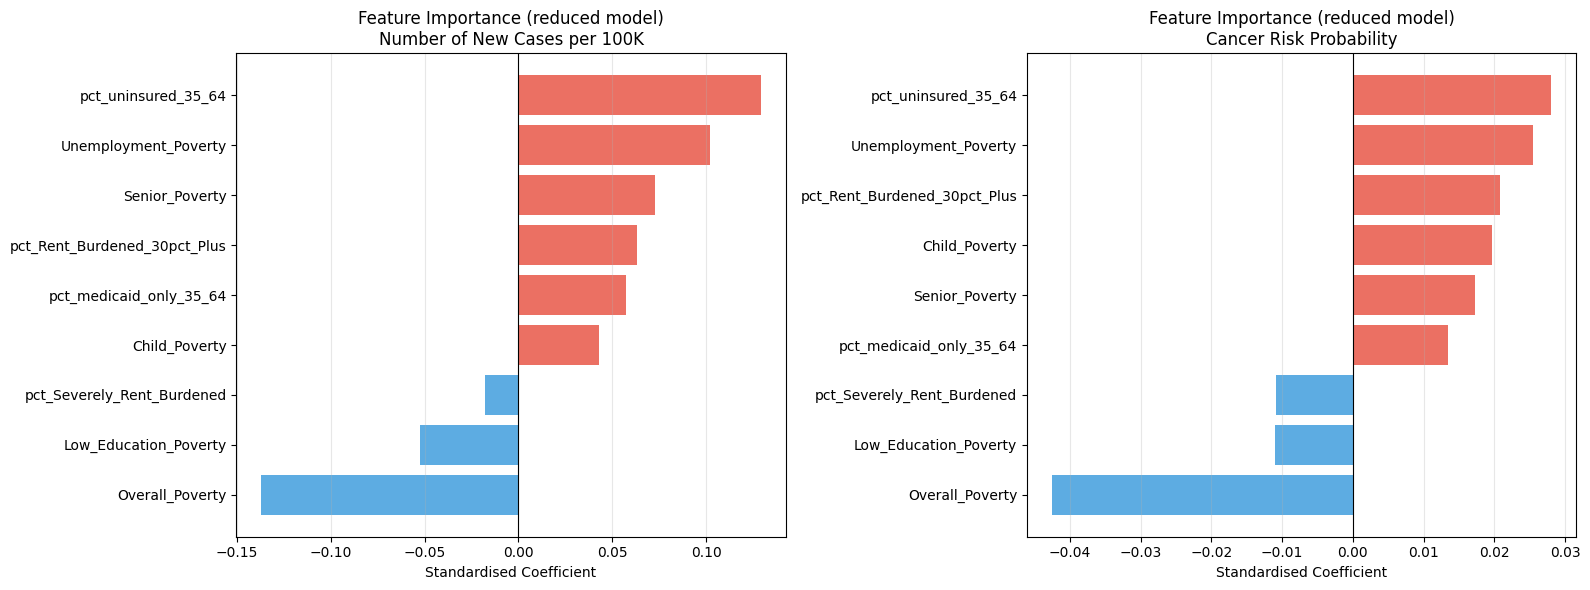

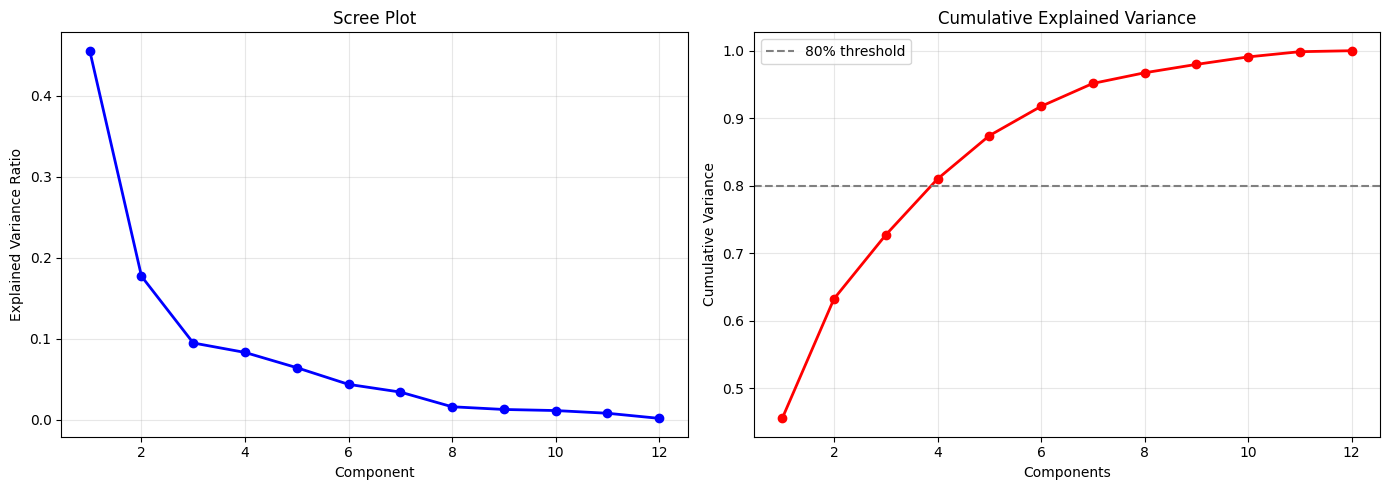

Components needed for 80% variance: 4

PC1 (45.6% variance) — top contributors:
  pct_private_insurance_35_64        : +0.393
  pct_government_insurance_35_64     : -0.376
  pct_medicaid_only_35_64            : -0.363
  Overall_Poverty                    : -0.352
  Child_Poverty                      : -0.341

PC2 (17.7% variance) — top contributors:
  pct_Severely_Rent_Burdened         : +0.622
  pct_Rent_Burdened_30pct_Plus       : +0.572
  pct_uninsured_35_64                : -0.300
  pct_employer_only_35_64            : +0.293
  Overall_Poverty                    : +0.222

PC3 (9.5% variance) — top contributors:
  Senior_Poverty                     : +0.709
  pct_uninsured_35_64                : -0.432
  Low_Education_Poverty              : +0.287
  Unemployment_Poverty               : +0.256
  Child_Poverty                      : -0.241


In [10]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr_mx = analysis_df[all_vars].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_mx, mask=np.triu(np.ones_like(corr_mx, dtype=bool)),
            annot=True, cmap='RdBu_r', center=0, square=True, fmt='.3f',
            cbar_kws={'shrink': .8})
plt.title('Comprehensive Multivariate Correlation Matrix — Cancer vs SDOH', fontsize=14)
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

for outcome in outcome_vars:
    print(f"\n{outcome.upper()} — predictors ranked by |r|:")
    corrs = sorted(
        [(pred, *pearsonr(analysis_df[outcome], analysis_df[pred])) for pred in predictor_vars],
        key=lambda x: abs(x[1]), reverse=True)
    for pred, r, pval in corrs:
        sig = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else ''
        print(f"  {pred:35s} r={r:+.3f}  p={pval:.3f} {sig}")

# ── Multiple regression: reduced predictor set to address multicollinearity ───
# Insurance variables (pct_private, pct_government, pct_employer, pct_uninsured)
# must mathematically sum to ~100%, making them collinear in the same model.
# FIX: keep only non-redundant insurance predictors:
#   - pct_uninsured_35_64:     directly measures lack of access
#   - pct_medicaid_only_35_64: captures low-income public coverage specifically
# Drop pct_private_insurance, pct_government_insurance, pct_employer_only —
# these are largely collinear with each other and with pct_uninsured.
regression_insurance = ['pct_uninsured_35_64', 'pct_medicaid_only_35_64']
regression_vars = regression_insurance + poverty_vars + rent_vars

print(f"\nRegression uses {len(regression_vars)} predictors (reduced from {len(predictor_vars)})")
print("Removed collinear insurance variables: pct_private_insurance_35_64,")
print("  pct_government_insurance_35_64, pct_employer_only_35_64")

X_sc = StandardScaler().fit_transform(analysis_df[regression_vars])
models = {}
for outcome in outcome_vars:
    y = analysis_df[outcome]
    m = LinearRegression().fit(X_sc, y)
    models[outcome] = {
        'model': m,
        'r2':    r2_score(y, m.predict(X_sc)),
        'coefs': list(zip(regression_vars, m.coef_))
    }
    print(f"\n{outcome.upper()}: R²={models[outcome]['r2']:.3f} "
          f"({models[outcome]['r2']*100:.1f}% variance explained)")
    for feat, coef in sorted(models[outcome]['coefs'], key=lambda x: abs(x[1]), reverse=True):
        print(f"  {feat:35s}: {coef:+.3f} {'↑' if coef>0 else '↓'}")

# ── Feature importance bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, outcome in zip(axes, outcome_vars):
    coefs = sorted(models[outcome]['coefs'], key=lambda x: x[1])
    feats, vals = zip(*coefs)
    ax.barh(feats, vals,
            color=['#e74c3c' if v > 0 else '#3498db' for v in vals], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Feature Importance (reduced model)\n{outcome}', fontsize=12)
    ax.set_xlabel('Standardised Coefficient'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

# ── PCA scree + cumulative variance (uses full predictor set — PCA handles collinearity) ──
# Note: PCA does not require independent predictors, so we use all predictor_vars here.
X_sc2  = StandardScaler().fit_transform(analysis_df[predictor_vars])
pca    = PCA().fit(X_sc2)
cumvar = np.cumsum(pca.explained_variance_ratio_)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_, 'bo-', linewidth=2)
ax1.set_title('Scree Plot'); ax1.set_xlabel('Component')
ax1.set_ylabel('Explained Variance Ratio'); ax1.grid(True, alpha=0.3)
ax2.plot(range(1, len(cumvar)+1), cumvar, 'ro-', linewidth=2)
ax2.axhline(0.8, color='gray', linestyle='--', label='80% threshold')
ax2.set_title('Cumulative Explained Variance'); ax2.set_xlabel('Components')
ax2.set_ylabel('Cumulative Variance'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
n_for_80 = int(np.argmax(cumvar >= 0.8) + 1)
print(f"Components needed for 80% variance: {n_for_80}")
loadings = pd.DataFrame(pca.components_[:3].T,
                         columns=['PC1', 'PC2', 'PC3'], index=predictor_vars)
for i, pc in enumerate(['PC1', 'PC2', 'PC3']):
    print(f"\n{pc} ({pca.explained_variance_ratio_[i]*100:.1f}% variance) — top contributors:")
    for var in loadings[pc].abs().nlargest(5).index:
        print(f"  {var:35s}: {loadings.loc[var, pc]:+.3f}")


## 3. Model diagnostics

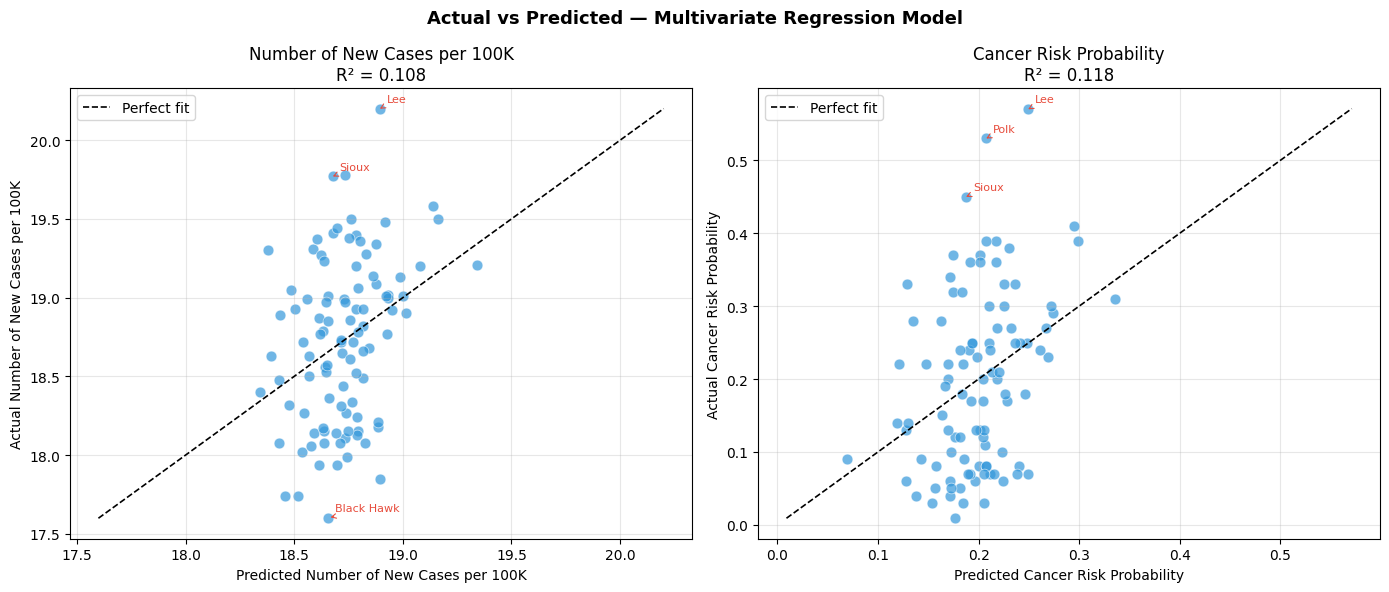

In [11]:
# ── Actual vs Predicted scatter (annotates highest-residual counties) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
X_sc = StandardScaler().fit_transform(analysis_df[regression_vars])  # matches reduced regression model
for ax, outcome in zip(axes, outcome_vars):
    y      = analysis_df[outcome]
    m      = models[outcome]['model']
    y_pred = m.predict(X_sc)
    r2     = models[outcome]['r2']
    resid  = (y - y_pred).abs()

    ax.scatter(y_pred, y, alpha=0.7, s=60, color='#3498db', edgecolors='white', linewidth=0.5)
    lims = [min(y.min(),y_pred.min())-0.001, max(y.max(),y_pred.max())+0.001]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect fit')

    # FIX: use positional integer index (analysis_df is reset_index'd) for numpy alignment
    for idx in resid.nlargest(3).index:
        pos    = analysis_df.index.get_loc(idx)
        county = analysis_df.loc[idx,'County']
        ax.annotate(county, xy=(y_pred[pos], y.iloc[pos]),
                    fontsize=8, color='#e74c3c',
                    arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=0.8),
                    xytext=(5,5), textcoords='offset points')

    ax.set_xlabel(f'Predicted {outcome}'); ax.set_ylabel(f'Actual {outcome}')
    ax.set_title(f'{outcome}\nR² = {r2:.3f}'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Actual vs Predicted — Multivariate Regression Model', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 4. Partial regression plots

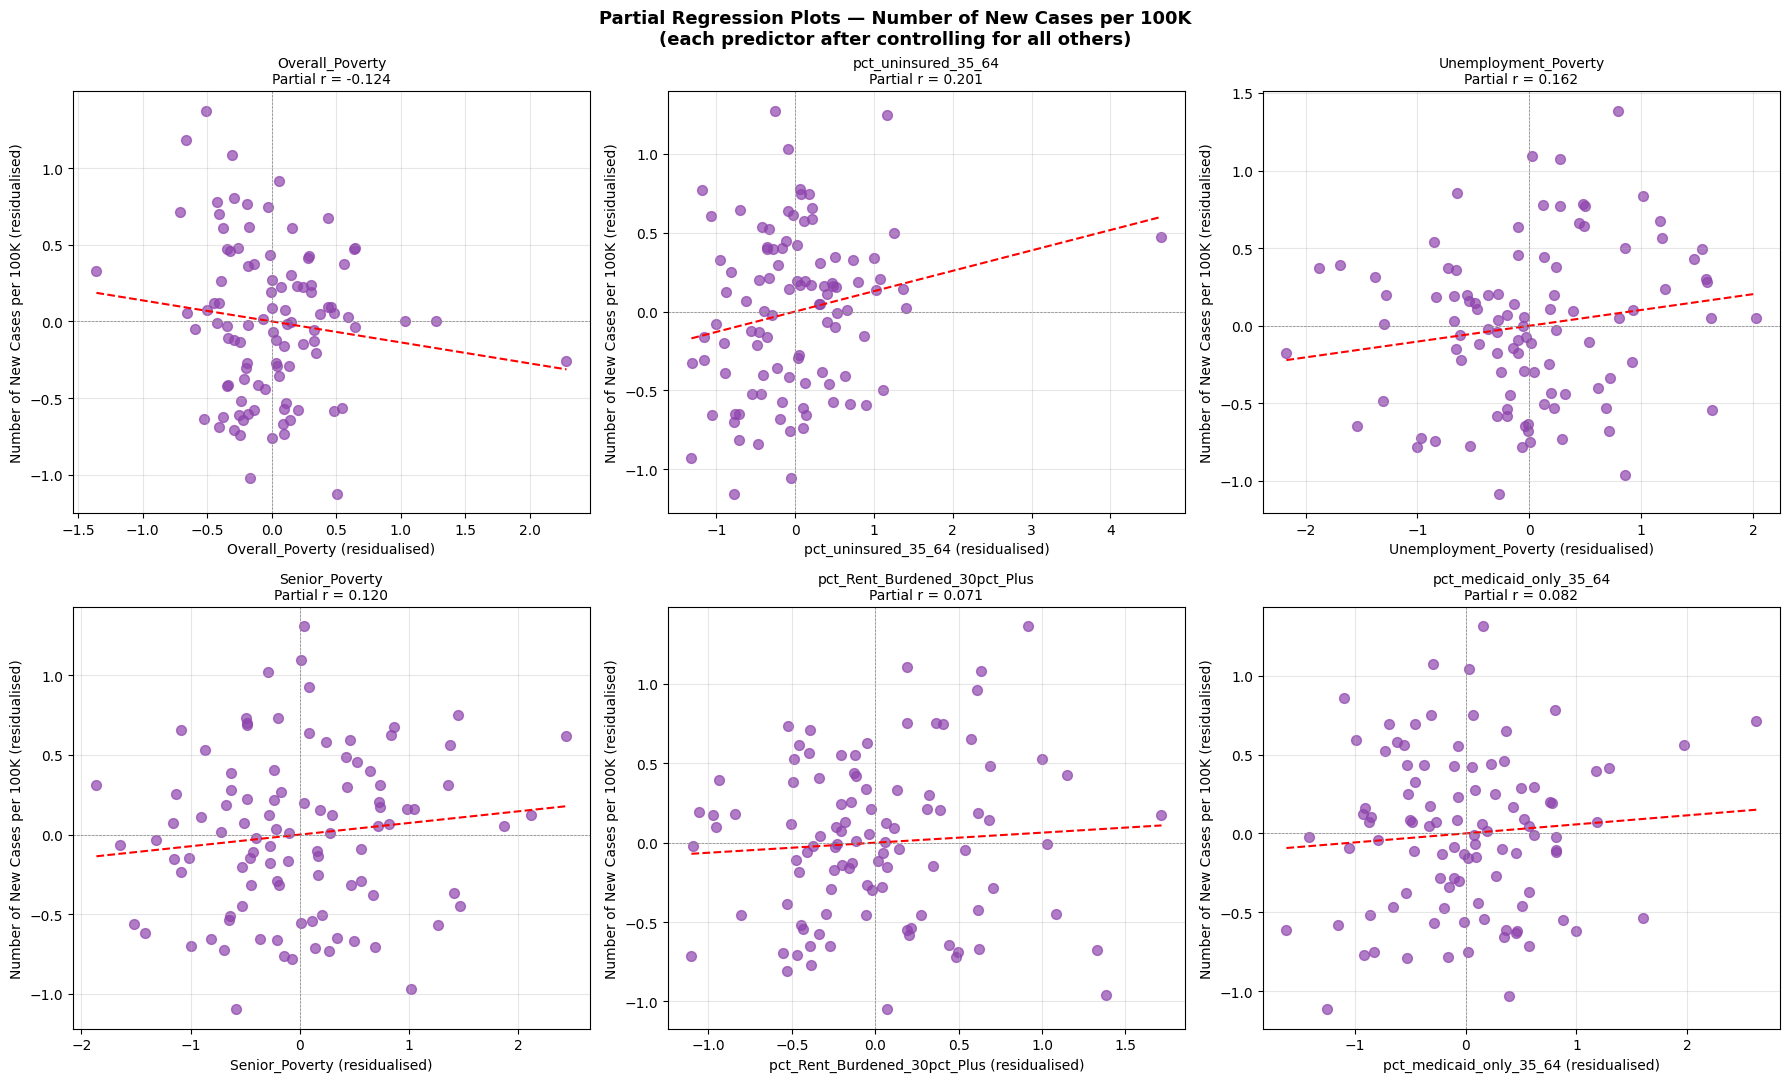

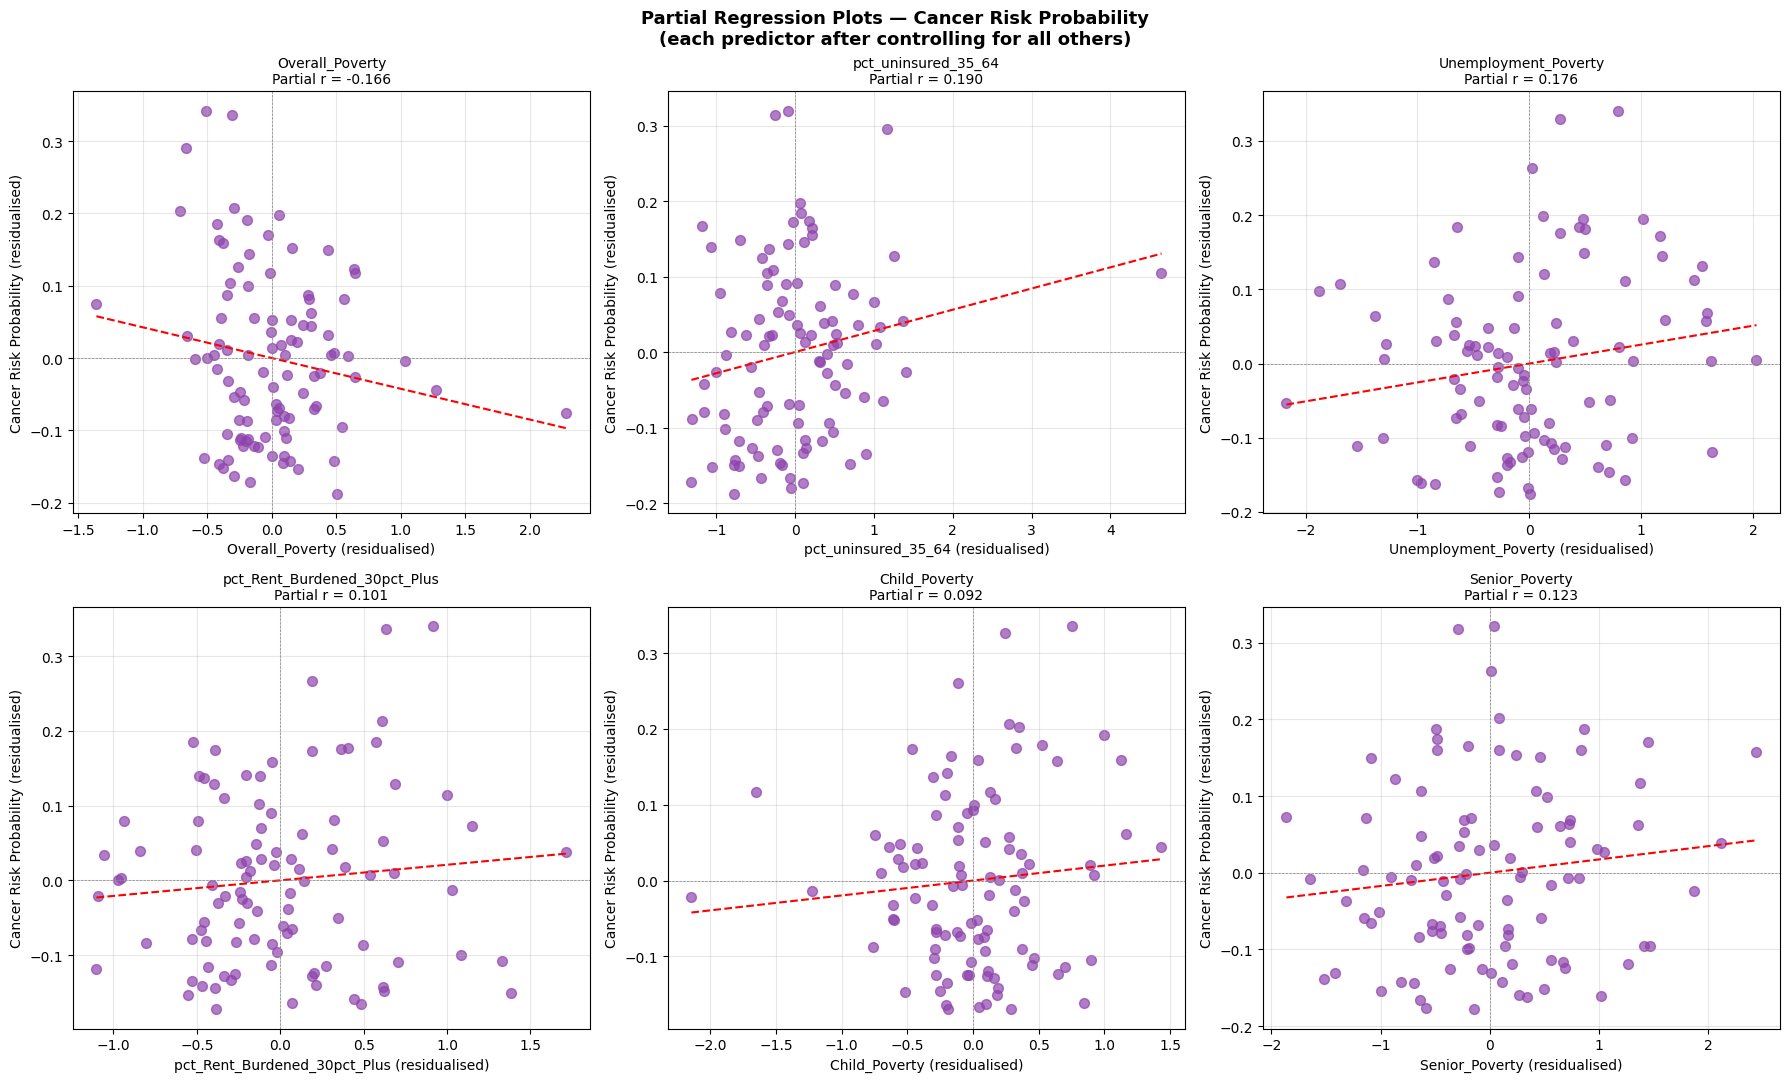

In [12]:
# ── Partial regression plots: each predictor controlling for all others ────────
X_sc_df = pd.DataFrame(StandardScaler().fit_transform(analysis_df[regression_vars]),
                        columns=regression_vars, index=analysis_df.index)

for outcome in outcome_vars:
    y         = analysis_df[outcome]
    full_coefs= sorted(zip(regression_vars, models[outcome]['model'].coef_),
                       key=lambda x: abs(x[1]), reverse=True)
    top_vars  = [p for p,_ in full_coefs[:6]]

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(f'Partial Regression Plots — {outcome}\n'
                 f'(each predictor after controlling for all others)', fontsize=13, fontweight='bold')
    for ax, var in zip(axes.flat, top_vars):
        others  = [v for v in regression_vars if v != var]
        resid_y = y - LinearRegression().fit(X_sc_df[others], y).predict(X_sc_df[others])
        resid_x = X_sc_df[var] - LinearRegression().fit(X_sc_df[others], X_sc_df[var]).predict(X_sc_df[others])
        xs      = np.sort(resid_x)
        ax.scatter(resid_x, resid_y, alpha=0.7, s=50, color='#8e44ad')
        ax.plot(xs, np.poly1d(np.polyfit(resid_x,resid_y,1))(xs), 'r--', linewidth=1.5)
        r = np.corrcoef(resid_x, resid_y)[0,1]
        ax.set_title(f'{var}\nPartial r = {r:.3f}', fontsize=10)
        ax.set_xlabel(f'{var} (residualised)'); ax.set_ylabel(f'{outcome} (residualised)')
        ax.axhline(0,color='grey',linewidth=0.5,linestyle='--')
        ax.axvline(0,color='grey',linewidth=0.5,linestyle='--')
        ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


## 5. PCA biplot

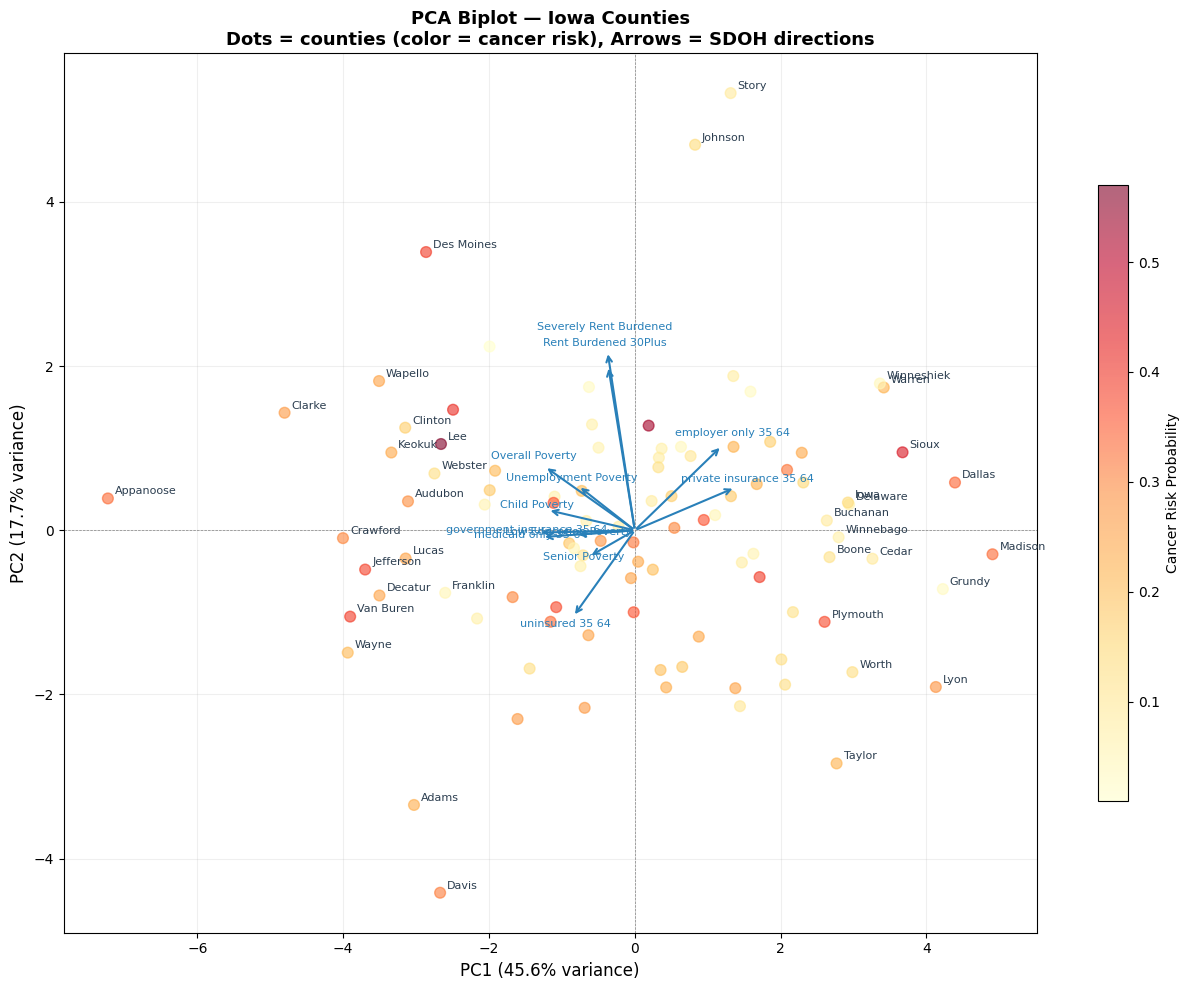

In [13]:
# ── PCA biplot: county scores + variable loading arrows ──────────────────────
X_sc3  = StandardScaler().fit_transform(analysis_df[predictor_vars])
pca2   = PCA(n_components=2)
scores = pca2.fit_transform(X_sc3)
loads  = pca2.components_.T

fig, ax = plt.subplots(figsize=(13, 10))
sc = ax.scatter(scores[:,0], scores[:,1], alpha=0.6, s=60,
                c=analysis_df['Cancer Risk Probability'], cmap='YlOrRd', zorder=3)
plt.colorbar(sc, ax=ax, label='Cancer Risk Probability', shrink=0.7)
for i, county in enumerate(analysis_df['County']):
    if abs(scores[i,0]) > 2.5 or abs(scores[i,1]) > 2.5:
        ax.annotate(county, xy=(scores[i,0],scores[i,1]), fontsize=8, color='#2c3e50',
                    xytext=(5,3), textcoords='offset points')
scale = 3.5
for i, var in enumerate(predictor_vars):
    ax.annotate('', xy=(loads[i,0]*scale,loads[i,1]*scale), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.5))
    ax.text(loads[i,0]*scale*1.12, loads[i,1]*scale*1.12,
            var.replace('pct_','').replace('_',' '), fontsize=8, color='#2980b9', ha='center')
ax.axhline(0,color='grey',linewidth=0.5,linestyle='--')
ax.axvline(0,color='grey',linewidth=0.5,linestyle='--')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Biplot — Iowa Counties\nDots = counties (color = cancer risk), Arrows = SDOH directions',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.2); plt.tight_layout(); plt.show()


## 7. Geographic model residuals

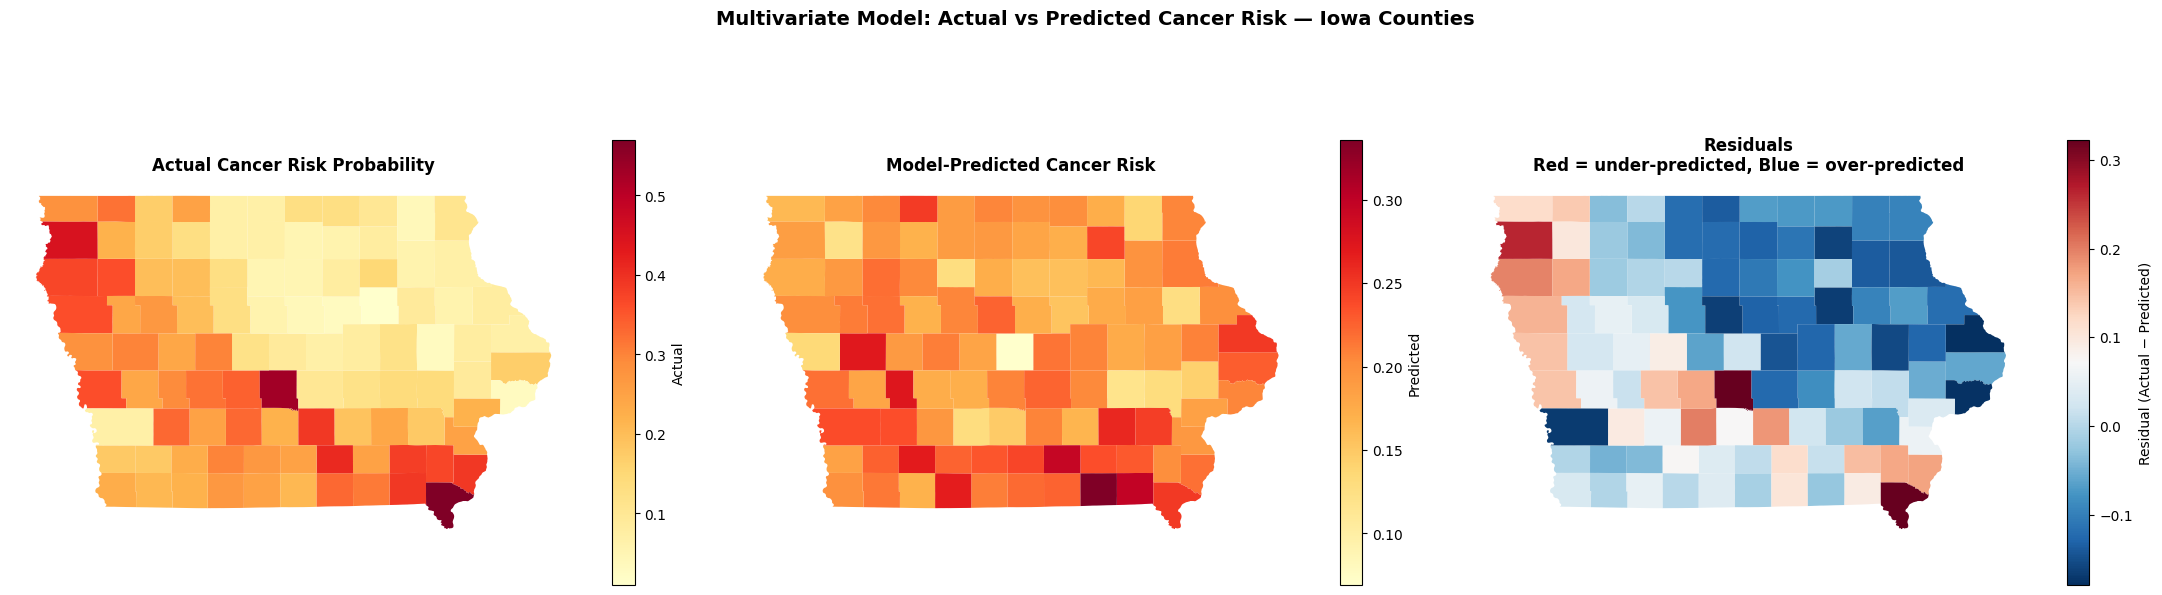

In [14]:
# ── Iowa choropleth: Actual vs Model-Predicted Cancer Risk ────────────────────
gdf      = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip")
iowa_gdf = gdf[gdf['STATEFP']=='19'].copy()
iowa_gdf['NAME'] = iowa_gdf['NAME'].str.strip()

# regression_vars (9 features) must match what the model was fitted on
X_sc4 = StandardScaler().fit_transform(analysis_df[regression_vars])
y_actual    = analysis_df['Cancer Risk Probability'].values
y_predicted = models['Cancer Risk Probability']['model'].predict(X_sc4)
residuals   = y_actual - y_predicted

map_input = pd.DataFrame({'County':    analysis_df['County'].values,
                           'Actual':    y_actual,
                           'Predicted': y_predicted,
                           'Residual':  residuals})
map_df = iowa_gdf.merge(map_input, left_on='NAME', right_on='County', how='left')

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
map_df.plot(column='Actual',    ax=axes[0], legend=True, cmap='YlOrRd',
            missing_kwds={'color':'lightgrey'}, legend_kwds={'label':'Actual','shrink':0.7})
axes[0].set_title('Actual Cancer Risk Probability', fontsize=12, fontweight='bold'); axes[0].axis('off')
map_df.plot(column='Predicted', ax=axes[1], legend=True, cmap='YlOrRd',
            missing_kwds={'color':'lightgrey'}, legend_kwds={'label':'Predicted','shrink':0.7})
axes[1].set_title('Model-Predicted Cancer Risk', fontsize=12, fontweight='bold'); axes[1].axis('off')
map_df.plot(column='Residual',  ax=axes[2], legend=True, cmap='RdBu_r',
            missing_kwds={'color':'lightgrey'}, legend_kwds={'label':'Residual (Actual − Predicted)','shrink':0.7})
axes[2].set_title('Residuals\nRed = under-predicted, Blue = over-predicted',
                   fontsize=12, fontweight='bold'); axes[2].axis('off')
plt.suptitle('Multivariate Model: Actual vs Predicted Cancer Risk — Iowa Counties',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Multivariate Analysis — Key Findings

**Insurance access is the dominant SDOH predictor of colorectal cancer in Iowa.** The correlation table ranks the top four significant predictors consistently across both outcomes:

1. Private insurance (35–64): r = −0.278 to −0.280 (p < 0.01)
2. Employer-only insurance (35–64): r = −0.273 to −0.275 (p < 0.01)
3. Medicaid-only (35–64): r = +0.199 to +0.203 (p < 0.05)
4. Uninsured (35–64): r = +0.199 to +0.206 (p < 0.05)

Poverty and rent burden variables are all non-significant individually (p > 0.10).

**The regression model (R² ≈ 0.11) explains modest variance.** After removing collinear insurance variables, the reduced 9-predictor model explains 10.8% of AAR variance and 11.8% of Cancer Risk Probability variance. The largest standardised coefficients are `pct_uninsured_35_64` (+0.129↑) and `Overall_Poverty` (−0.137↓, a suppressor effect), with unemployment and senior poverty contributing smaller positive effects. The low R² is expected at county level with only 99 observations — unmeasured factors such as rurality, screening access, and diet account for the majority of variation.

**PCA identifies three underlying patterns in the SDOH data:**
- **PC1 (45.6% of variance):** An insurance/poverty gradient — private insurance loads positively while Medicaid, government insurance, and poverty measures load negatively. This is the primary axis of socioeconomic variation across Iowa counties.
- **PC2 (17.7%):** A housing stress dimension — rent burden variables dominate this component, confirming that housing stress is a distinct pattern from insurance/poverty, even though it does not predict cancer outcomes.
- **PC3 (9.5%):** A senior vulnerability dimension — senior poverty loads strongly positive, with uninsured rate loading negatively, suggesting a separate cluster of counties with older, poorer populations.

Four components are needed to explain 80% of SDOH variance across Iowa counties.

**Bottom line:** Insurance coverage type — particularly private and employer-based versus uninsured or Medicaid-only — is the most consistent SDOH predictor of colorectal cancer burden in Iowa counties. Poverty and rent burden add little predictive value beyond insurance variables at this level of analysis.